Installing libraries

In [ ]:
!pip install SpeechRecognition
!pip install pipwin
!pipwin install pyaudio
!pip install pydub
!pip install gTTS

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.9/32.9 MB 25.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 20.0 MB/s eta 0:00:00
  Created wheel for pipwin: filename=pipwin-0.5.2-py2.py3-none-any.whl size=8770 sha256=d2697e0140f471d7bca1e630de52d89ce55581b058602df2f4350251f7fe3229
  Stored in directory: /root/.cache/pip/wheels/07/45/2e/51ee464b7c3407327439df34c2fc62f978a1e5084aaf23d201
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13706 sha256=a6a44b049ca9c7e36c178f2dfe9c1547ecb4f39678e67ed0ede3648d271f3a16
  Stored in directory: /root/.cache/pip/wheels/1a/b0/8c/4b75c4116c31f83c8f9f047231251e13cc74481cca4a78a9ce
  Created wheel for pyjsparser: filename=pyjsparser-2.7.1-py3-none-any.whl size=25982 sha256=d9b096ff57d12289cdd790e663568414f89011e10de9488369a9611a9a3ab2cf
  Stored in directory: /root/.cache/pip/wh

Fetching audio file

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving ftesting.m4a to ftesting.m4a


Converting audio file to .wav

In [ ]:
from pydub import AudioSegment

# Load the .m4a file
audio = AudioSegment.from_file("ftesting.m4a", format="m4a")

# Export as .wav
audio.export("output.wav", format="wav")

print("Conversion complete!")

Conversion complete!


Fetching text from voice

In [ ]:
import speech_recognition as sr

recognizer = sr.Recognizer()
with sr.AudioFile("output.wav") as source:
    audio = recognizer.record(source)

text = recognizer.recognize_google(audio)
print("You said:", text)

You said: I am at snacks I need to buy canned vegetables


NLP Logic

In [ ]:
import spacy
text1 = "I am at A1 take me to C3"
nlp = spacy.load("en_core_web_sm")
ruler = nlp.add_pipe("entity_ruler", before="ner")
#Identifying products
product_keywords = ['milk', 'eggs', 'yogurt', 'greek yogurt', 'cheese', 'butter', 'shampoo', 'conditioner', 'soap',
                    'body wash', 'face wash', 'lotion', 'bread', 'bagels', 'snacks', 'cookies', 'chips', 'canned vegetables',
                    'toothpaste', 'toothbrush', 'mouthwash', 'floss', 'detergent', 'dish soap']

product_patterns = []
for item in product_keywords:
    tokens = item.lower().split()
    pattern = [{"LOWER": token} for token in tokens]
    product_patterns.append({"label": "Product", "pattern": pattern})
# Identifying Aisles
patterns = [
    {"label": "Aisle", "pattern": [{"TEXT": {"REGEX": "^[A-Za-z]\\d{1,4}$"}}]},

    {"label": "Aisle", "pattern": [
        {"TEXT": {"REGEX": "^[A-Za-z]$"}},
        {"IS_DIGIT": True}
    ]},
    {"label": "Entrance", "pattern":[{"LOWER":"entrance"}]}
]
ruler.add_patterns(patterns+product_patterns)
doc = nlp(text1)
#Gather names of all locations
entities = []
for ent in doc.ents:
    if ent.label_ == "Product" or ent.label_ == "Aisle" or ent.label_ == "Entrance":
        entities.append({
            "text": ent.text,
            "start": ent.start,
            "end": ent.end,
            "label": ent.label_
        })
#Using token based checking to determine Source and destination
for ent in entities:
    start = ent["start"]
    token_before = doc[start - 1].text.lower() if start > 0 else ""

    if token_before in ["from", "at"]:
        ent["role"] = "Source"
    elif token_before in ["to","buy","need"]:
        ent["role"] = "Destination"
print(entities)

[{'text': 'A1', 'start': 3, 'end': 4, 'label': 'Aisle', 'role': 'Source'}, {'text': 'C3', 'start': 7, 'end': 8, 'label': 'Aisle', 'role': 'Destination'}]


Product Mapping & Store Grid

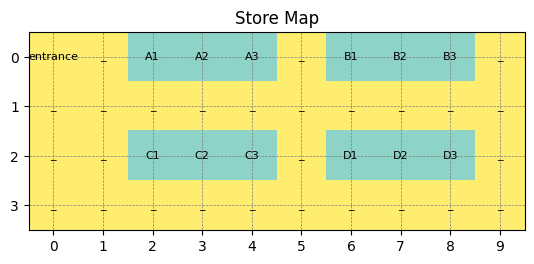

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import re
# ----------------------------
# Store Grid with Entrance
# ----------------------------
store_grid = [
    ['entrance','_','A1', 'A2', 'A3', '_', 'B1', 'B2', 'B3', '_'],
    ['_','_','_', '_', '_',  '_', '_',  '_',  '_',  '_'],
    ['_','_','C1','C2','C3', '_','D1', 'D2', 'D3', '_'],
    ['_','_','_','_','_','_','_','_','_', '_']
]
# ----------------------------
# Shelf to Product Mapping
# ----------------------------
shelf_and_products = {
    'A1': ['milk', 'eggs'],
    'A2': ['yogurt', 'greek yogurt'],
    'A3': ['cheese', 'butter'],
    'B1': ['shampoo', 'conditioner'],
    'B2': ['soap', 'body wash'],
    'B3': ['face wash', 'lotion'],
    'C1': ['bread', 'bagels'],
    'C2': ['snacks', 'cookies'],
    'C3': ['chips', 'canned vegetables'],
    'D1': ['toothpaste', 'toothbrush'],
    'D2': ['mouthwash', 'floss'],
    'D3': ['detergent', 'dish soap'],
}
# ----------------------------
# Generating Shelf to Position Mapping
# ----------------------------
shelf_position = {}
entrance_position = None

for i in range(len(store_grid)):
    for j in range(len(store_grid[0])):
        cell = store_grid[i][j]
        if cell == 'entrance':
            entrance_position = (i, j)
        elif cell != '_':
            shelf_position[cell] = (i, j)

# ----------------------------
# Generating Product to Position Mapping
# ----------------------------
product_position = {}

for shelf, products in shelf_and_products.items():
    if shelf in shelf_position:
        for product in products:
            product_position[product] = shelf_position[shelf]

# ----------------------------
# Lookup Functions
# ----------------------------
def find_product_location(product):
    if product in product_position:
        row, col = product_position[product]
        shelf = store_grid[row][col]
        return (row,col)
    else:
        return None

def list_products_on_shelf(shelf):
    return shelf_and_products.get(shelf, [])

def show_grid():
    for row in store_grid:
        print("  ".join(cell if cell != '_' else '__' for cell in row))

def map_cell(cell):
    if cell == '.':
        return 0
    elif re.fullmatch(r'[A-Za-z]\d+', cell):
        return 1
    else:
        return 2

grid_np = np.array([[map_cell(cell) for cell in row] for row in store_grid])

plt.imshow(grid_np, cmap='Set3')
plt.xticks(np.arange(len(store_grid[0])))
plt.yticks(np.arange(len(store_grid)))
plt.grid(True, color='gray', linestyle='--', linewidth=0.5)
plt.title("Store Map")
for i in range(len(store_grid)):
    for j in range(len(store_grid[0])):
        plt.text(j, i, store_grid[i][j], ha='center', va='center', fontsize=8, color='black')

Navigation Algorithm

[(1, 2), (1, 1), (2, 1), (3, 1), (3, 2), (3, 3), (3, 4)]


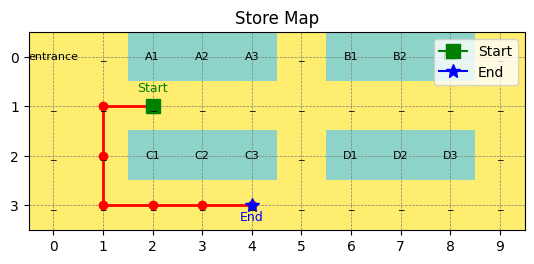

In [ ]:
from collections import deque

def shortest_path(grid, start, end):
    rows, cols = len(grid), len(grid[0])
    visited = [[False]*cols for _ in range(rows)]
    directions = [(-1,0), (1,0), (0,-1), (0,1)]  # Up, Down, Left, Right

    queue = deque()
    queue.append((start, [start]))  # (current_pos, path_so_far)
    visited[start[0]][start[1]] = True

    while queue:
        (x, y), path = queue.popleft()

        if (x, y) == end:
            return path

        for dx, dy in directions:
            nx, ny = x + dx, y + dy
            if 0 <= nx < rows and 0 <= ny < cols and not visited[nx][ny]:
                cell = grid[nx][ny]
                if cell == '_' or cell.lower() == 'entrance'.lower():
                    visited[nx][ny] = True
                    queue.append(((nx, ny), path + [(nx, ny)]))

    return None

for ent in entities:
    text = ent['text'].strip()  # clean whitespace

    if ent['role'] == 'Source':
        if ent['label'] == 'Product':
            product = text.lower()
            pos = find_product_location(product)
            if pos:
                sou = (pos[0] + 1, pos[1])

        elif ent['label'] == 'Aisle':
            aisle = text.upper()
            pos = shelf_position.get(aisle)
            if pos:
                sou = (pos[0] + 1, pos[1])

        elif ent['label'] == 'Entrance':
            sou = entrance_position

    elif ent['role'] == 'Destination':
        if ent['label'] == 'Product':
            product = text.lower()
            pos = find_product_location(product)
            if pos:
                dest = (pos[0] + 1, pos[1])

        elif ent['label'] == 'Aisle':
            aisle = text.upper()
            pos = shelf_position.get(aisle)
            if pos:
                dest = (pos[0] + 1, pos[1])

        elif ent['label'] == 'Entrance':
            dest = entrance_position

path = shortest_path(store_grid, sou, dest)
print(path)

def map_cell(cell):
    if cell == '.':
        return 0
    elif re.fullmatch(r'[A-Za-z]\d+', cell):
        return 1
    else:
        return 2

grid_np = np.array([[map_cell(cell) for cell in row] for row in store_grid])

plt.imshow(grid_np, cmap='Set3')
plt.xticks(np.arange(len(store_grid[0])))
plt.yticks(np.arange(len(store_grid)))
plt.grid(True, color='gray', linestyle='--', linewidth=0.5)
plt.title("Store Map")

# Optional: annotate with cell labels
for i in range(len(store_grid)):
    for j in range(len(store_grid[0])):
        plt.text(j, i, store_grid[i][j], ha='center', va='center', fontsize=8, color='black')
if path:
    ys, xs = zip(*path)  # Unpack path
    plt.plot(xs, ys, color='red', linewidth=2, marker='o')  # Draw path

    # Mark the starting point
    start_x, start_y = xs[0], ys[0]
    plt.plot(start_x, start_y, marker='s', color='green', markersize=10, label='Start')
    plt.text(start_x, start_y - 0.3, 'Start', color='green', fontsize=9, ha='center')

    # Optionally, mark the end point too
    end_x, end_y = xs[-1], ys[-1]
    plt.plot(end_x, end_y, marker='*', color='blue', markersize=10, label='End')
    plt.text(end_x, end_y + 0.3, 'End', color='blue', fontsize=9, ha='center')

plt.legend()
plt.show()

Voice for path

In [ ]:
from gtts import gTTS
from pydub import AudioSegment
import os
from IPython.display import Audio

def subtract_tuples(t1, t2):
    return tuple(x - y for x, y in zip(t1, t2))

# 1. Create Instructions
directions = ['straight', 'right', 'backward', 'left']
dir_vectors = [(1, 0), (0, 1), (-1, 0), (0, -1)]  # up, right, down, left

if path[0] != (0,0):
 current_dir_idx = 0
else:
  current_dir_idx = 2
instructions = []

for i in range(len(path) - 1):
    move = subtract_tuples(path[i], path[i + 1])
    if move not in dir_vectors:
        continue  # ignore diagonal or invalid moves

    target_idx = dir_vectors.index(move)
    delta = (target_idx - current_dir_idx) % 4

    if delta == 0:
        instructions.append("Take 1 step forward")
    elif delta == 1:
        instructions.append("Turn left")
        instructions.append("Take 1 step forward")
    elif delta == 2:
        instructions.append("Turn 180")
        instructions.append("Take 1 step forward")
    elif delta == 3:
        instructions.append("Turn right")
        instructions.append("Take 1 step forward")

    current_dir_idx = target_idx
instructions.append("You have arrived")

# 2. Save each part as separate mp3 files
filenames = []
for i, text in enumerate(instructions):
    tts = gTTS(text,slow="True")
    filename = f"instruction_{i}.mp3"
    tts.save(filename)
    filenames.append(filename)

# 3. Merge all audio files into one
final_audio = AudioSegment.empty()
pause = AudioSegment.silent(duration=700)

for fname in filenames:
    final_audio += AudioSegment.from_mp3(fname)
    final_audio += pause

# 4. Export the final combined mp3
final_audio.export("final_instructions.mp3", format="mp3")
print("Final audio saved as final_instructions.mp3")

# 5. Optional: Play in Colab
Audio("final_instructions.mp3")

Final audio saved as final_instructions.mp3
